# Pattern generation example notebook

We aim to solve patterns for a model of vegetation growth using Julia's FourierFlows. The differential equation [1] corresponds to:
\begin{align}
\partial_t n = - \omega n + a n^2 - b n^3 + \epsilon \nabla^2 n + \alpha (\nabla^2 n) n + \delta || \vec{\nabla} n||^2 + \beta (\nabla^4n)n + \gamma \nabla^4n - \gamma \nabla^4n
\end{align}

[1] D. Ruiz-Reynés, F. Schönsberg, E. Hernández-García, and D. Gomila, “General model
for vegetation patterns including rhizome growth”, [Physical Review Research 2, 023402
(2020)](https://link.aps.org/doi/10.1103/PhysRevResearch.2.023402)

## Importing necessary libraries

In [1]:
using FourierFlows, Random, Plots
using LinearAlgebra: mul!, ldiv!
using DelimitedFiles
#using CUDA # uncomment to use GPU

## Loading functions

In [2]:
include("generating_funcs.jl")

stable_sol (generic function with 1 method)

## Setting the parameters

In [3]:
dev = CPU() # or GPU()

# Setting Numerical parameters and time-stepping parameters
nx = 128                # grid resolution
ny = 128                # grid resolution
stepper = "ETDRK4"      # timestepper
dt = 1e-4               # timestep (s)
nsteps = 100            # total number of time-steps
nsub = 10000            # writing step

10000

In [4]:
# Setting Physical parameters
Lx = 20           # Domain length (m)
Ly = 20           # Domain length (m)
w  = 0.45         # Local net death rate in the linear regime
a = 1.39          # facilitative interaction
b = 1.0           # competitive interaction
epsilon = 1.15e-2 # diffusion constant 
alpha = -1.78     # interaction parameters to ensure existence of bare soil solution and positive density
delta = 1.03e-2   # effect of clonal grwoth by rhizome elongation
beta = -1.0       # interaction parameters to ensure existence of bare soil solution and positive density

IC = stable_sol(w, a, b)

gamma = - beta * abs(IC)

0.8767278184538622

## Construct the structs

In [5]:
# First, we prepare the grid and equation
grid = TwoDGrid(dev; nx=nx,ny=ny, Lx=Lx,Ly=Ly,aliased_fraction=0)

params = Params(w, a, b, epsilon, alpha, delta, beta, gamma)
vars = Vars(grid)
equation = Equation(params, grid)

# We load the problem
prob = FourierFlows.Problem(equation, stepper, dt, grid, vars, params)

Problem
  ├─────────── grid: grid (on CPU)
  ├───── parameters: params
  ├────── variables: vars
  ├─── state vector: sol
  ├─────── equation: eqn
  ├────────── clock: clock
  │                  └──── dt: 0.0001
  └──── timestepper: ETDRK4TimeStepper

## Define and plot initial conditions

In [6]:
# Setting homogeneous solution with noise as initial condition
IC = stable_sol(w, a, b)
n0 = ones((grid.nx, grid.ny)) * IC + randn((grid.nx, grid.ny))*0.1

# uncomment if you want to use a previous pattern (changing the path) as initial condition:
#pattern = readdlm("path/previous_pattern.txt", skipstart=1)
#pattern = reshape(pattern, (nx, ny))
#n0 = pattern

set_n!(prob, n0)

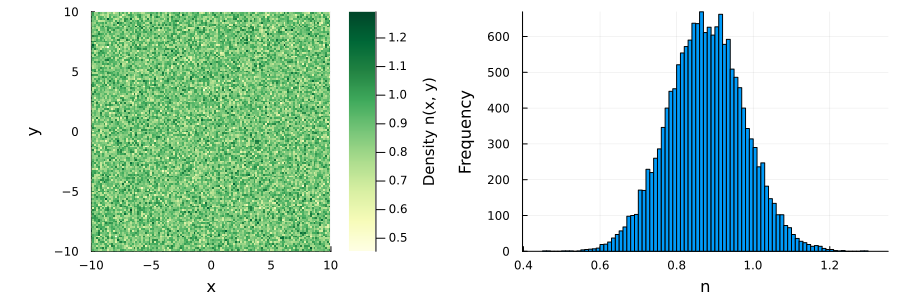

In [7]:
# Subplots of the initial condition
fig1 = heatmap(grid.x, grid.y, n0, aspect_ratio= :equal, xlims= (-Lx/2, Lx/2), ylims= (-Ly/2, Ly/2),c = :YlGn,
                              xlabel="x",ylabel="y", colorbar_title="Density n(x, y)", leftmargin = (5, :mm), 
                              bottommargin = (5, :mm))
fig2 = histogram(vec(n0), bins=100,  xlabel="n", ylabel="Frequency", legend=false)

subplots = plot(fig1, fig2, layout=(1,2),size=(900,300))

display(subplots)

## Run simulations

In [8]:
last_result = 0

@time for j = 0:nsteps #Loop for integrating the system

    updatevars!(prob)
    stepforward!(prob, nsub)
    
    nmax = maximum(prob.vars.n)
    # We print the timestep, the time, and the maximum density (useful to check if everything is going alright)
    println(j, "\t", prob.clock.t, "\t", nmax) 

    if isnan(nmax)
        print("Exception: NaN")
        break
    end

    last_result = Array(prob.vars.n)
end

0	0.9999999999999062	0.8856219653496221
1	1.9999999999997962	0.8957835778332304
2	3.0000000000019065	0.9082367900401864
3	4.000000000004016	0.9235737151452253
4	5.000000000001686	0.9430506662100013
5	5.999999999999355	0.9681865289741831
6	6.999999999997025	1.000896765328779
7	7.999999999994694	1.0433317411132685
8	8.999999999992363	1.0979024930725783
9	9.999999999990033	1.1663369427648453
10	10.999999999987702	1.2491812799504602
11	11.999999999985372	1.3566984673935913
12	12.999999999983041	1.4700317033585877
13	13.99999999998071	1.5691787564536894
14	14.99999999997838	1.6392629393930291
15	15.99999999997605	1.6812054370038267
16	16.99999999997372	1.7053565804226083
17	17.99999999997139	1.7204180904545512
18	18.99999999996906	1.7300337956923693
19	19.99999999996673	1.7340839825753132
20	20.9999999999644	1.7320976836897097
21	21.999999999962068	1.7244447520586925
22	22.999999999959737	1.7093922797679655
23	23.999999999957407	1.6894889976694045
24	24.999999999955076	1.6697915804026524
25

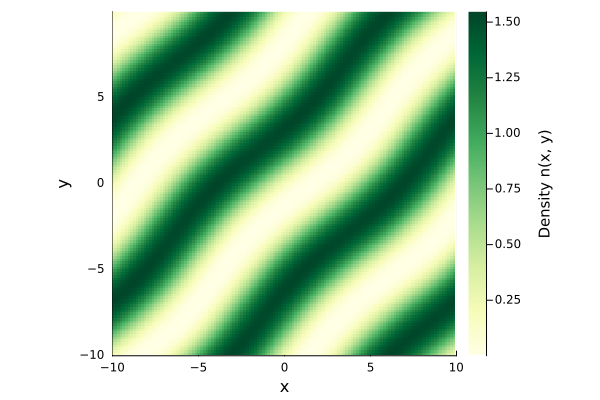

In [9]:
heatmap(grid.x, grid.y, Array(last_result), c=:YlGn, aspect_ratio= :equal, xlims= (-Lx/2, Lx/2), 
        xlabel="x",ylabel="y", colorbar_title=" \nDensity n(x, y)", right_margin = 2Plots.mm)

#savefig("name.pdf")

## Saving data

In [ ]:
# Saving result as a .txt if desired
result_save = reduce(vcat, last_result)

f = open("path/pattern_name.txt", "w")

write(f, "# shape=($nx, $ny)\n")
writedlm(f, result_save)

close(f)

## Some of our examples

Here are some results of hexagonal and striped patterns obtained in our work. We used GPU to speed up the process.

In [12]:
# Creating the grid
# Setting Numerical parameters 
nx = 256                # grid resolution
ny = 256                # grid resolution
# Setting Physical parameters
Lx = 40          # Domain length (m)
Ly = 40         # Domain length (m)

grid = TwoDGrid(dev; nx=nx,ny=ny, Lx=Lx,Ly=Ly,aliased_fraction=0)
x = grid.x
y = grid.y

-20.0:0.15625:19.84375

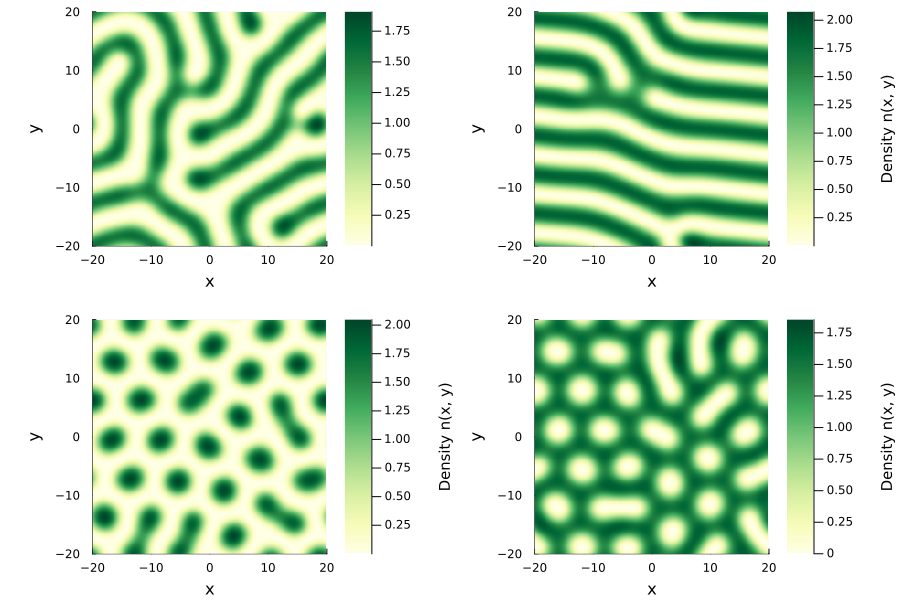

In [14]:
# Plotting the examples

pattern = readdlm("examples/example1.txt", skipstart=1)
pattern = reshape(pattern, (nx, ny))

fig1 = heatmap(y,x, Array(pattern), aspect_ratio= :equal, xlims= (-Lx/2, Lx/2), ylims= (-Ly/2, Ly/2),c = :YlGn,
               xlabel="x",ylabel="y", leftmargin = (5, :mm), bottommargin = (5, :mm))

pattern = readdlm("examples/example2.txt", skipstart=1)
pattern = reshape(pattern, (nx, ny))

fig2 = heatmap(y,x, Array(pattern), aspect_ratio= :equal, xlims= (-Lx/2, Lx/2),ylims= (-Ly/2, Ly/2),c = :YlGn,
               xlabel="x",ylabel="y", colorbar_title=" \nDensity n(x, y)")

pattern = readdlm("examples/example3.txt", skipstart=1)
pattern = reshape(pattern, (nx, ny))

fig3 = heatmap(y,x, Array(pattern), aspect_ratio= :equal, xlims= (-Lx/2, Lx/2), ylims= (-Ly/2, Ly/2),c = :YlGn,
               xlabel="x",ylabel="y", colorbar_title=" \nDensity n(x, y)")

pattern = readdlm("examples/example4.txt", skipstart=1)
pattern = reshape(pattern, (nx, ny))

fig4 = heatmap(y,x, Array(pattern), aspect_ratio= :equal, xlims= (-Lx/2, Lx/2), ylims= (-Ly/2, Ly/2),c = :YlGn,
               xlabel="x",ylabel="y", colorbar_title=" \nDensity n(x, y)")

subplots = plot(fig1, fig2, fig3, fig4, layout=(2,2), size=(900,600))